# 得点遷移パターン別の「次の得点」までの待ち時間分析

本notebookは `recent_score.ipynb` のセクション6以降（「同じ得点から同じ得点へ」の各パターン、
および1-1・2-2の先読み分析）を独立させたものです。データ読み込みや、ヒストグラム・
Kaplan-Meier曲線の描画に使う共通のヘルパー関数は、このnotebook内で改めて用意しているため、
`recent_score.ipynb` を実行していなくても、このnotebook単体で先頭から実行できます。

セクション番号は `recent_score.ipynb`（セクション1〜5）から続く形で、セクション6から始まります。


## 共通の前処理

`recent_score.ipynb` のセクション1・3・4・5と同じ内容（import・日本語フォント設定、
データ読み込み、ヒストグラム用のビン幅・統計計算・描画関数、Kaplan-Meier曲線用の
`lifelines` の読み込み、検定結果に星印を付ける `stars` 関数）を、このnotebookでも
そのまま再定義する。


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフ内の日本語（タイトル・軸ラベル等）が文字化けしないよう、macOS標準の日本語フォントを指定する。
# （Windows等、別環境で開く場合は "Meiryo" や "Yu Gothic" などお使いの環境にある日本語フォント名に変更してください）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False


/Users/fujitaharukanin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


In [3]:
BIN_WIDTH = 5  # 分（各セクションのヒストグラムで共通のビン幅。ビン境界自体は各セクションごとに
                # そのセクションの最大待ち時間から個別に決める）


In [4]:
BAR_COLOR = "#6699CC"
MEAN_COLOR = "#E69F00"
MEDIAN_COLOR = "#009E73"
MODE_COLOR = "#CC79A7"


def compute_stats(vals, bin_edges):
    n = len(vals)
    if n == 0:
        return dict(n=0, mean=np.nan, median=np.nan, mode=np.nan, var=np.nan, std=np.nan,
                    counts=np.zeros(len(bin_edges) - 1))
    counts, _ = np.histogram(vals, bins=bin_edges)
    mode_idx = int(np.argmax(counts))
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    return dict(n=n, mean=np.mean(vals), median=np.median(vals), mode=mode_val,
                var=np.var(vals), std=np.std(vals), counts=counts)


def plot_one(ax, vals, title, bin_edges):
    stats = compute_stats(vals, bin_edges)
    ax.bar(bin_edges[:-1], stats["counts"], width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)
    if stats["n"] > 0:
        ax.axvline(stats["mean"], color=MEAN_COLOR, linestyle="-", linewidth=1.8,
                    label=f"平均={stats['mean']:.1f}分")
        ax.axvline(stats["median"], color=MEDIAN_COLOR, linestyle="--", linewidth=1.8,
                    label=f"中央値={stats['median']:.1f}分")
        ax.axvline(stats["mode"], color=MODE_COLOR, linestyle=":", linewidth=1.8,
                    label=f"最頻値={stats['mode']:.1f}分")
        var_handle = Line2D([], [], color="none", label=f"分散={stats['var']:.1f}分²")
        std_handle = Line2D([], [], color="none", label=f"標準偏差={stats['std']:.1f}分")
        handles, labels = ax.get_legend_handles_labels()
        handles += [var_handle, std_handle]
        labels += [var_handle.get_label(), std_handle.get_label()]
        ax.legend(handles, labels, fontsize=8, loc="upper right", framealpha=0.9)
    ax.set_title(f"{title} (n={stats['n']})", fontsize=11)
    ax.set_xlabel("次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)
    return stats


In [5]:
try:
    from lifelines import KaplanMeierFitter
except ModuleNotFoundError:
    # このノートブックのカーネルに lifelines が入っていない場合、自動でインストールする。
    # 同一プロセス内で numpy/matplotlib 等の依存が更新されると壊れることがあるため、
    # インストール後はあえて処理を止め、カーネル再起動を促す。
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )


In [6]:
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


## 6. 1-1からの遷移を計算する（追いついた側が次に得点 vs 追いつかれた側が次に得点で場合分け）

ここでは、**1-1という状態そのものから、次にどちらが得点するか**で場合分けする（この後の
セクション9〜17では、逆に「ある状態にどちらの側の得点で到達したか」という視点で同様の
場合分けを行う）。1-1は必ずどちらか一方の
チームが同点にした直後の状態であり、同点にした側（追いついた側）と、それまでリードして
いたが追いつかれた側（追いつかれた側）に分かれる。

- **追いついた側が次に得点**: 同点にした勢いのまま、そのチームが続けて先取点を奪うケース
- **追いつかれた側が次に得点**: 同点にされた直後に、元のリード側が再び得点し突き放すケース

**注**: 元のノートブックの区分6・7（`tied_was_leading`・`tied_was_trailing`）は「その
チーム自身の次の得点」までの待ち時間を、途中で相手が何点入れても関係なく計算していた
（0-0以外の全ての同点状態を対象）。一方、ここでの分析は**1-1という特定のスコアに限定**し、
かつ「1-1になった直後に実際に次に得点したのはどちらか」という**試合内で実際に起きた
直近の1イベント**で場合分けする点が異なる。したがって、1-1に到達した試合はここでの
2区分のいずれか一方に必ず分類され（その後得点がなかった試合を除く）、除外や重複はない。


In [7]:
TRANSITION_11_CATEGORY_LABELS = {
    "leveler_next": "追いついた側が次に得点",
    "original_leader_next": "追いつかれた側が次に得点",
}
TRANSITION_11_CATEGORY_ORDER = ["leveler_next", "original_leader_next"]


def build_1_1_transition_events(df):
    """
    goals_and_red_cards の df から、試合ごとに得点系列（(home_score, away_score) の推移）を
    追跡し、ちょうど「1-1」の状態に到達した試合を対象に、1-1になった直後に次に得点したのが
    「追いついた側」（1-1にした側）か「追いつかれた側」（それまでリードしていた側）かで
    category を分け、1-1になった時刻から次の得点までの待ち時間を計算する。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]
        state_time = {(0, 0): 0.0}
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        idx = state_index.get((1, 1))
        if idx is None:
            continue  # この試合は1-1にならなかった

        # state_seq[idx] は sides[idx-1] の得点によって作られた状態 → その得点者が「追いついた側」
        leveler_side = sides[idx - 1]

        if idx >= len(state_seq) - 1:
            continue  # 1-1が試合最後の得点で、その後得点がない（打ち切り扱いとして除外）

        next_side = sides[idx]  # 1-1の直後に実際に得点したチーム
        category = "leveler_next" if next_side == leveler_side else "original_leader_next"
        waiting_time = state_time[state_seq[idx + 1]] - state_time[(1, 1)]

        records.append({**meta, "category": category, "waiting_time": waiting_time})

    return pd.DataFrame(records)


transition_11_events_df = build_1_1_transition_events(df_all)
print(f"観測数: {len(transition_11_events_df)}")
transition_11_events_df["category"].value_counts().reindex(TRANSITION_11_CATEGORY_ORDER)


観測数: 538


category
leveler_next            273
original_leader_next    265
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_1_1_transition_diagram.png


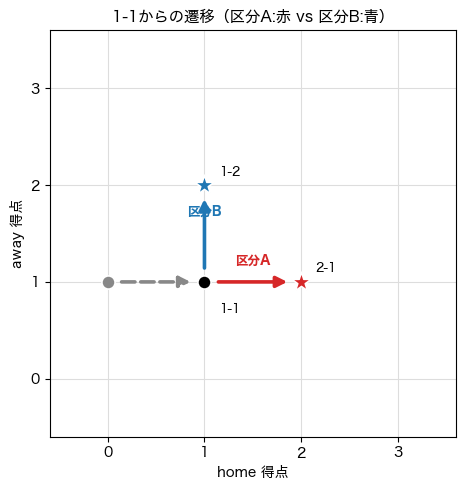

In [8]:
# 各セクション共通で使う、home×awayグリッド上に遷移を図示するためのヘルパー関数
from matplotlib.patches import FancyArrowPatch

RED = "#D62728"
BLUE = "#1F77B4"
GRAY = "#888888"


def draw_score_grid(ax, xmax, ymax, title):
    ax.set_xlim(-0.6, xmax + 0.6)
    ax.set_ylim(-0.6, ymax + 0.6)
    ax.set_xticks(range(xmax + 1))
    ax.set_yticks(range(ymax + 1))
    ax.grid(True, color="#dddddd", linewidth=0.8, zorder=0)
    ax.set_xlabel("home 得点")
    ax.set_ylabel("away 得点")
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")


def draw_point(ax, xy, color="black", marker="o", size=90, label=None, label_offset=(0.15, 0.1)):
    ax.scatter([xy[0]], [xy[1]], s=size, color=color, marker=marker, zorder=5,
               edgecolor="white", linewidth=1.2)
    if label:
        ax.annotate(label, xy, xytext=(xy[0] + label_offset[0], xy[1] + label_offset[1]), fontsize=9)


def draw_arrow(ax, p1, p2, color, lw=2.6, style="-", label=None, label_offset=(0, 0.15)):
    arrow = FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=16, color=color,
                             linewidth=lw, linestyle=style, zorder=4, shrinkA=10, shrinkB=10)
    ax.add_patch(arrow)
    if label:
        mx = (p1[0] + p2[0]) / 2 + label_offset[0]
        my = (p1[1] + p2[1]) / 2 + label_offset[1]
        ax.text(mx, my, label, fontsize=9, color=color, ha="center", va="bottom", fontweight="bold")


fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 3, 3, "1-1からの遷移（区分A:赤 vs 区分B:青）")
draw_point(ax, (0, 1), color=GRAY)
draw_point(ax, (1, 1), color="black", label="1-1", label_offset=(0.15, -0.32))
draw_point(ax, (2, 1), color=RED, marker="*", size=220, label="2-1")
draw_point(ax, (1, 2), color=BLUE, marker="*", size=220, label="1-2")
draw_arrow(ax, (0, 1), (1, 1), GRAY, style="--")
draw_arrow(ax, (1, 1), (2, 1), RED, label="区分A")
draw_arrow(ax, (1, 1), (1, 2), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_1_1_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 7. ヒストグラムのビンを共通化し、既存フォーマットで描画する（1-1からの遷移）

`BIN_WIDTH`・`compute_stats`・`plot_one`（セクション3・4で定義）を再利用する。


最大待ち時間: 80.75分 -> ビン境界: 0〜85分（5分刻み、17ビン）
保存しました: ./figures/recent_score_1_1_transition_histograms.png


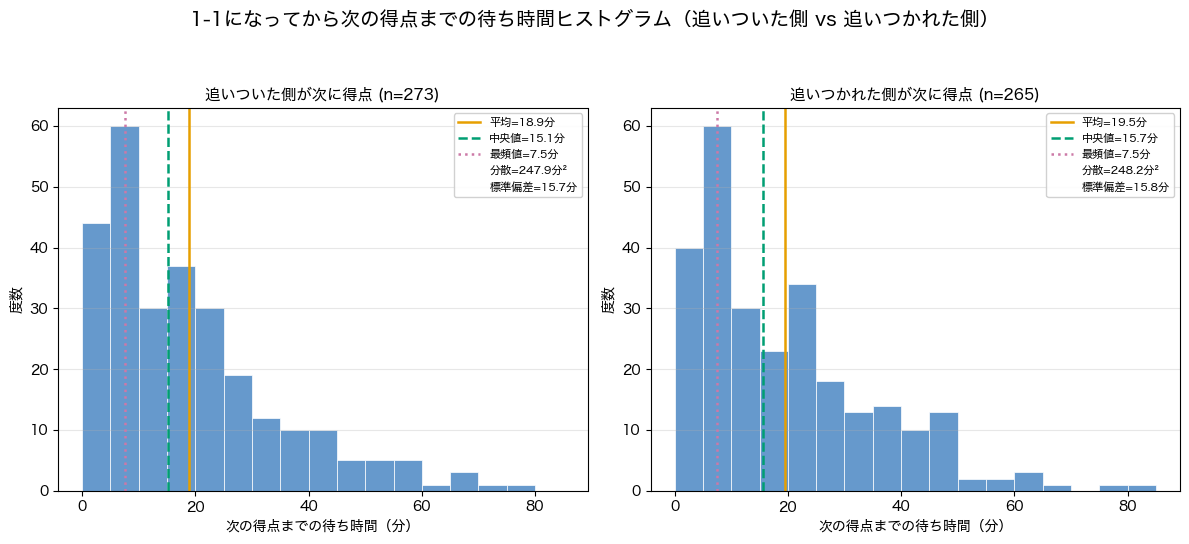

In [9]:
TRANSITION_11_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_11_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_11_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_11_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_11_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_11_stats = {}
for i, cat in enumerate(TRANSITION_11_CATEGORY_ORDER):
    vals = transition_11_events_df.loc[transition_11_events_df["category"] == cat, "waiting_time"].values
    transition_11_stats[cat] = plot_one(axes[i], vals, TRANSITION_11_CATEGORY_LABELS[cat], TRANSITION_11_BIN_EDGES)

fig.suptitle("1-1になってから次の得点までの待ち時間ヒストグラム（追いついた側 vs 追いつかれた側）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_1_1_transition_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 8. Kaplan-Meier曲線とログランク検定（追いついた側 vs 追いつかれた側・打ち切りなし、1-1からの遷移）

`transition_11_events_df` の `waiting_time` をそのまま「イベント
発生時間」として扱う（`event_observed` は全件True、打ち切りなし。セクション5と同様の打ち切りなし近似）。追いついた側 vs
追いつかれた側の2群比較なので、`lifelines.statistics.logrank_test` による標準的な2標本
ログランク検定を行う。


保存しました: ./figures/recent_score_1_1_transition_km_curves.png


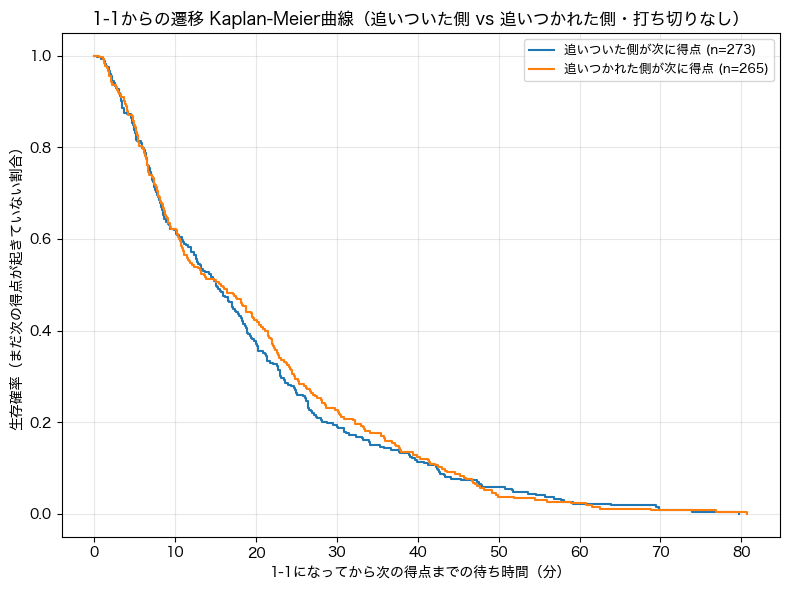

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_11 = KaplanMeierFitter()

for cat in TRANSITION_11_CATEGORY_ORDER:
    vals = transition_11_events_df.loc[transition_11_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_11.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_11_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_11.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("1-1になってから次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ次の得点が起きていない割合）")
ax.set_title("1-1からの遷移 Kaplan-Meier曲線（追いついた側 vs 追いつかれた側・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_1_1_transition_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [11]:
from lifelines.statistics import logrank_test

vals_leveler_11 = transition_11_events_df.loc[transition_11_events_df["category"] == "leveler_next", "waiting_time"].values
vals_original_leader_11 = transition_11_events_df.loc[transition_11_events_df["category"] == "original_leader_next", "waiting_time"].values

logrank_result_11 = logrank_test(
    vals_leveler_11, vals_original_leader_11,
    event_observed_A=None, event_observed_B=None,
)

print("=== 1-1からの遷移: 追いついた側 vs 追いつかれた側 のログランク検定 ===")
print(f"n(追いついた側)={len(vals_leveler_11)}, n(追いつかれた側)={len(vals_original_leader_11)}")
logrank_result_11.print_summary()
print(f"\np値: {logrank_result_11.p_value:.6e}{stars(logrank_result_11.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 1-1からの遷移: 追いついた側 vs 追いつかれた側 のログランク検定 ===
n(追いついた側)=273, n(追いつかれた側)=265



p値: 6.690457e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


---

## 同じ得点から同じ得点へ（直近の得点チームは違うよ）

以下のセクション9〜29は、いずれも「最終的に到達する（あるいは経由する）得点自体は同じだが、
そこに至る直前の状態（＝直近の得点チーム）が異なる」という共通の構造を持つ分析をまとめた
ものである。実際のデータでの試合数を確認したところ、以下の結果になった。

| パターン | 区分A | 区分B | 総数 | 区分A件数 | 区分B件数 | 採用 |
|---|---|---|---|---|---|---|
| 2-1→3-1 | 1-1→2-1→3-1 | 2-0→2-1→3-1 | 261 | 177 | 84 | ✅ |
| 2-1→2-2 | 1-1→2-1→2-2 | 2-0→2-1→2-2 | 210 | 133 | 77 | ✅ |
| 4-2 | 3-2→4-2 | 4-1→4-2 | 59 | 40 | 19 | ✅ |
| 3-2 | 2-2→3-2 | 3-1→3-2 | 161 | 93 | 68 | ✅ |
| 4-3 | 3-3→4-3 | 4-2→4-3 | 17 | 9 | 8 | ❌ |
| 3-1（到達） | 2-1→3-1 | 3-0→3-1 | 349 | 261 | 88 | ✅ |
| 4-1 | 3-1→4-1 | 4-0→4-1 | 145 | 116 | 29 | ✅ |
| 2-2（先読み） | 追いついた側が次に得点 | 追いつかれた側が次に得点 | 93 | 41 | 52 | ✅ |
| 3-3（先読み） | 追いついた側が次に得点 | 追いつかれた側が次に得点 | 9 | 4 | 5 | ❌ |

4-3（総数17件、少数派8件）と3-3の先読み（総数9件、少数派4件）は、4-2（総数59件、少数派19件）
よりもさらに標本数が少なく、検定の検出力がほぼ確保できないため対象外とする。それ以外の7パターン
（2-1→3-1・2-1→2-2・4-2・3-2・3-1（到達）・4-1・2-2（先読み））を、以下のセクション9〜29で
それぞれ実装する。

4-2（セクション15）のロジックを一般化した `build_arrival_events(df, leader_score, trailer_score)`
関数を3-2・3-1（到達）・4-1で共通利用し（セクション18で定義）、1-1の先読み（セクション6）の
ロジックを一般化した `build_tie_forward_events(df, tie_score)` 関数を2-2の先読みに使う
（セクション27で定義）。


## 9. 2-1→3-1の遷移を計算する（1-1経由 vs 2-0経由で場合分け）

区分1〜7とは別に、**得点系列の中でちょうど「2-1」の状態になり、その直後の得点で3-1になった
試合**（3-1になった後にさらに得点が入っていても構わない）を対象に、「2-1になってから3-1に
なるまでの待ち時間」を、2-1になる直前の状態で場合分けして比較する。

- **1-1 → 2-1 → 3-1**: 同点を破ってリードを奪った直後に、そのまま2点リードに広げたケース
- **2-0 → 2-1 → 3-1**: 2点リードされていたチーム（ビハインド側）が初めて得点して2-1にした
  直後に、リード側がすぐに突き放したケース

**注**: ホーム・アウェイどちらがリードしているかは区別せず、リード側の得点：ビハインド側の
得点が2：1であれば「2-1」として扱う（例えばアウェイが2点・ホームが1点の (home, away)=(1, 2)
も「2-1」として含める）。得点は1点ずつしか増えないため、2-1の直前の状態は必ず1-1か2-0の
いずれかであり、2-1の直後の状態は必ず3-1（リード側の得点）か2-2（ビハインド側の得点）の
いずれかになる。ここでは直後が3-1になったケースのみを対象とし、直後に2-2になった試合
（この時点で「2-1→3-1」の遷移が起きなかった試合）は対象外とする。


In [12]:
TRANSITION_CATEGORY_LABELS = {
    "from_1_1": "1-1 → 2-1 → 3-1",
    "from_2_0": "2-0 → 2-1 → 3-1",
}
TRANSITION_CATEGORY_ORDER = ["from_1_1", "from_2_0"]


def build_2_1_to_3_1_events(df):
    """
    goals_and_red_cards の df から、試合ごとに得点系列（(home_score, away_score) の推移）を
    追跡し、ちょうど「2-1」の状態（リード側2点・ビハインド側1点。home/awayどちらがリードして
    いてもよい）になり、かつその直後の得点イベントでリード側がさらに得点して「3-1」になった
    試合を対象に、2-1になった時刻から3-1になった時刻までの待ち時間を計算する。
    2-1になる直前の状態が「1-1」だったか「2-0」だったかで category を分ける
    （3-1になった後にさらに得点が入っていても、この待ち時間には影響しない）。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]          # (0,0)からの (home_score, away_score) の推移
        state_time = {(0, 0): 0.0}    # 各状態に到達した時刻（分）
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        # home がリードする (2, 1) と、away がリードする (1, 2) の両方を「2-1」として調べる
        for h, a in [(2, 1), (1, 2)]:
            idx = state_index.get((h, a))
            if idx is None or idx >= len(state_seq) - 1:
                continue  # 2-1に到達していない、または2-1が試合最後の得点（その後の得点なし）

            prev_state = state_seq[idx - 1]
            next_state = state_seq[idx + 1]
            if h == 2:
                prev_from_tie, prev_from_2_0, next_to_3_1 = (1, 1), (2, 0), (3, 1)
            else:
                prev_from_tie, prev_from_2_0, next_to_3_1 = (1, 1), (0, 2), (1, 3)

            if next_state != next_to_3_1:
                continue  # 2-1の直後が3-1でない（ビハインド側が追いついた）→対象外

            if prev_state == prev_from_tie:
                category = "from_1_1"
            elif prev_state == prev_from_2_0:
                category = "from_2_0"
            else:
                continue  # 理論上あり得ないが安全のため

            records.append({
                **meta, "category": category,
                "waiting_time": state_time[next_to_3_1] - state_time[(h, a)],
            })

    return pd.DataFrame(records)


transition_events_df = build_2_1_to_3_1_events(df_all)
print(f"観測数: {len(transition_events_df)}")
transition_events_df["category"].value_counts().reindex(TRANSITION_CATEGORY_ORDER)


観測数: 261


category
from_1_1    177
from_2_0     84
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_2_1_to_3_1_diagram.png


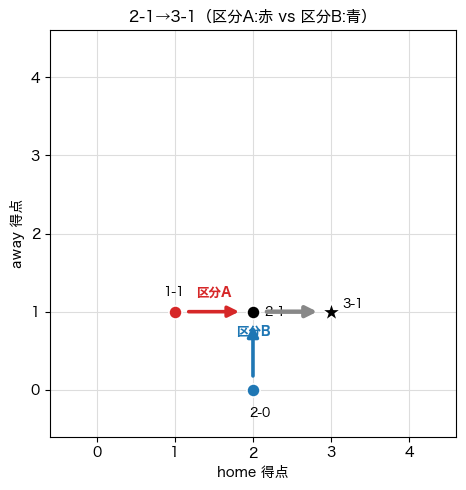

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 4, 4, "2-1→3-1（区分A:赤 vs 区分B:青）")
draw_point(ax, (1, 1), color=RED, label="1-1", label_offset=(-0.15, 0.2))
draw_point(ax, (2, 0), color=BLUE, label="2-0", label_offset=(-0.05, -0.35))
draw_point(ax, (2, 1), color="black", label="2-1", label_offset=(0.15, -0.05))
draw_point(ax, (3, 1), color="black", marker="*", size=220, label="3-1", label_offset=(0.15, 0.05))
draw_arrow(ax, (1, 1), (2, 1), RED, label="区分A")
draw_arrow(ax, (2, 0), (2, 1), BLUE, label="区分B")
draw_arrow(ax, (2, 1), (3, 1), GRAY, lw=3.2)
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_3_1_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 10. ヒストグラムのビンを共通化し、既存フォーマットで描画する

`BIN_WIDTH`・`compute_stats`・`plot_one` は区分1〜7のヒストグラム（セクション3・4）で定義した
ものをそのまま再利用する。ビン境界は、この2区分（1-1経由・2-0経由）の最大待ち時間から
改めて共通の上限を決め、既存のヒストグラムと同一の見た目（バー・平均/中央値/最頻値の
縦線・凡例）で描画する。


最大待ち時間: 75.08分 -> ビン境界: 0〜80分（5分刻み、16ビン）
保存しました: ./figures/recent_score_2_1_to_3_1_histograms.png


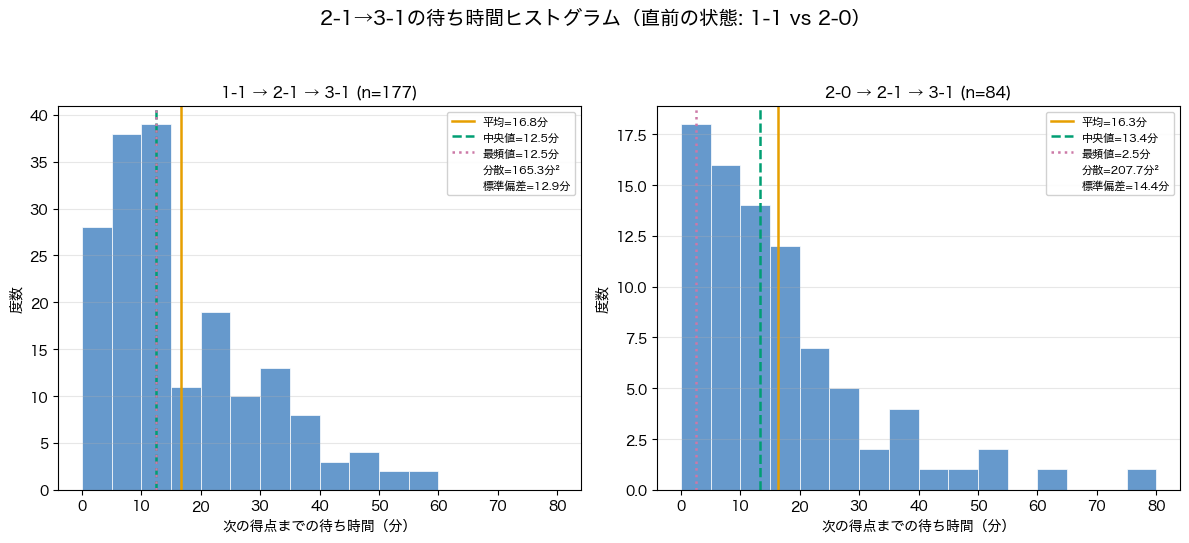

In [14]:
TRANSITION_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_stats = {}
for i, cat in enumerate(TRANSITION_CATEGORY_ORDER):
    vals = transition_events_df.loc[transition_events_df["category"] == cat, "waiting_time"].values
    transition_stats[cat] = plot_one(axes[i], vals, TRANSITION_CATEGORY_LABELS[cat], TRANSITION_BIN_EDGES)

fig.suptitle("2-1→3-1の待ち時間ヒストグラム（直前の状態: 1-1 vs 2-0）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_3_1_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 11. Kaplan-Meier曲線とログランク検定（1-1経由 vs 2-0経由・打ち切りなし）

セクション5と同様、`transition_events_df` の `waiting_time` をそのまま「イベント発生時間」として
扱う（`event_observed` は全件True、打ち切りなし）。この2区分はいずれも「2-1から3-1になった」
ことが確認できた試合のみで構成されており、区分1〜7のような「その後得点しなかったケースの
除外」に相当する打ち切りは生じない。

1-1経由 vs 2-0経由の2群比較なので、`lifelines.statistics.logrank_test` による標準的な
2標本ログランク検定を行う（有意水準の星印は、セクション5で定義した `stars` 関数を再利用する）。


保存しました: ./figures/recent_score_2_1_to_3_1_km_curves.png


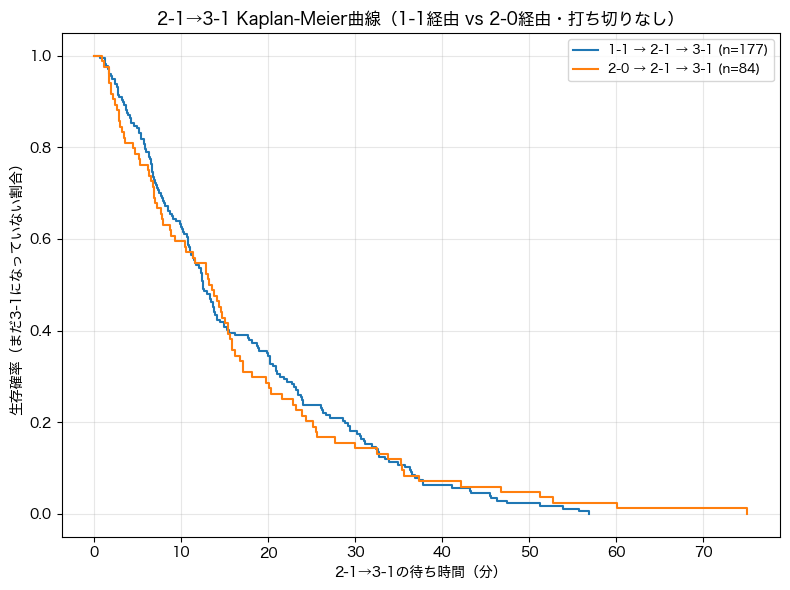

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition = KaplanMeierFitter()

for cat in TRANSITION_CATEGORY_ORDER:
    vals = transition_events_df.loc[transition_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition.fit(durations=vals, event_observed=None,
                        label=f"{TRANSITION_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("2-1→3-1の待ち時間（分）")
ax.set_ylabel("生存確率（まだ3-1になっていない割合）")
ax.set_title("2-1→3-1 Kaplan-Meier曲線（1-1経由 vs 2-0経由・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_3_1_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [16]:
from lifelines.statistics import logrank_test

vals_from_1_1 = transition_events_df.loc[transition_events_df["category"] == "from_1_1", "waiting_time"].values
vals_from_2_0 = transition_events_df.loc[transition_events_df["category"] == "from_2_0", "waiting_time"].values

logrank_result = logrank_test(
    vals_from_1_1, vals_from_2_0,
    event_observed_A=None, event_observed_B=None,
)

print("=== 2-1→3-1の待ち時間: 1-1経由 vs 2-0経由 のログランク検定 ===")
print(f"n(1-1経由)={len(vals_from_1_1)}, n(2-0経由)={len(vals_from_2_0)}")
logrank_result.print_summary()
print(f"\np値: {logrank_result.p_value:.6e}{stars(logrank_result.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 2-1→3-1の待ち時間: 1-1経由 vs 2-0経由 のログランク検定 ===
n(1-1経由)=177, n(2-0経由)=84



p値: 9.830774e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 12. 2-1→2-2の遷移を計算する（1-1経由 vs 2-0経由で場合分け）

セクション9〜11では「2-1になった直後にリード側がさらに得点して3-1になった」ケースを扱ったが、
ここではその逆に、**2-1になった直後にビハインド側が得点して同点（2-2）に追いついた試合**を
対象に、同様に2-1になる直前の状態で場合分けして比較する。

- **1-1 → 2-1 → 2-2**: 同点を破ってリードを奪った直後に、すぐ追いつかれたケース
- **2-0 → 2-1 → 2-2**: 2点リードされていたチーム（ビハインド側）が2-1まで詰めた直後に、
  さらに得点して同点に追いついたケース

**注**: セクション9と同様、ホーム・アウェイどちらがリードしているかは区別せず、リード側の
得点：ビハインド側の得点が2：1であれば「2-1」として扱う。2-1の直前の状態は必ず1-1か2-0の
いずれかであり、2-1の直後の状態は必ず3-1（リード側の得点）か2-2（ビハインド側の得点）の
いずれかになる。ここでは直後が2-2になったケースのみを対象とし、直後に3-1になった試合
（セクション9〜11で扱った試合）は対象外とする。


In [17]:
TRANSITION_22_CATEGORY_LABELS = {
    "from_1_1": "1-1 → 2-1 → 2-2",
    "from_2_0": "2-0 → 2-1 → 2-2",
}
TRANSITION_22_CATEGORY_ORDER = ["from_1_1", "from_2_0"]


def build_2_1_to_2_2_events(df):
    """
    goals_and_red_cards の df から、試合ごとに得点系列（(home_score, away_score) の推移）を
    追跡し、ちょうど「2-1」の状態（リード側2点・ビハインド側1点。home/awayどちらがリードして
    いてもよい）になり、かつその直後の得点イベントでビハインド側が得点して同点「2-2」になった
    試合を対象に、2-1になった時刻から2-2になった時刻までの待ち時間を計算する。
    2-1になる直前の状態が「1-1」だったか「2-0」だったかで category を分ける。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]
        state_time = {(0, 0): 0.0}
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        # home がリードする (2, 1) と、away がリードする (1, 2) の両方を「2-1」として調べる
        for h, a in [(2, 1), (1, 2)]:
            idx = state_index.get((h, a))
            if idx is None or idx >= len(state_seq) - 1:
                continue  # 2-1に到達していない、または2-1が試合最後の得点

            prev_state = state_seq[idx - 1]
            next_state = state_seq[idx + 1]
            if h == 2:
                prev_from_tie, prev_from_2_0 = (1, 1), (2, 0)
            else:
                prev_from_tie, prev_from_2_0 = (1, 1), (0, 2)
            next_to_2_2 = (2, 2)  # ホーム・アウェイどちらがリードしていても同点は(2,2)で一致する

            if next_state != next_to_2_2:
                continue  # 2-1の直後が2-2でない（リード側がさらに突き放した）→対象外

            if prev_state == prev_from_tie:
                category = "from_1_1"
            elif prev_state == prev_from_2_0:
                category = "from_2_0"
            else:
                continue  # 理論上あり得ないが安全のため

            records.append({
                **meta, "category": category,
                "waiting_time": state_time[next_to_2_2] - state_time[(h, a)],
            })

    return pd.DataFrame(records)


transition_22_events_df = build_2_1_to_2_2_events(df_all)
print(f"観測数: {len(transition_22_events_df)}")
transition_22_events_df["category"].value_counts().reindex(TRANSITION_22_CATEGORY_ORDER)


観測数: 210


category
from_1_1    133
from_2_0     77
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_2_1_to_2_2_diagram.png


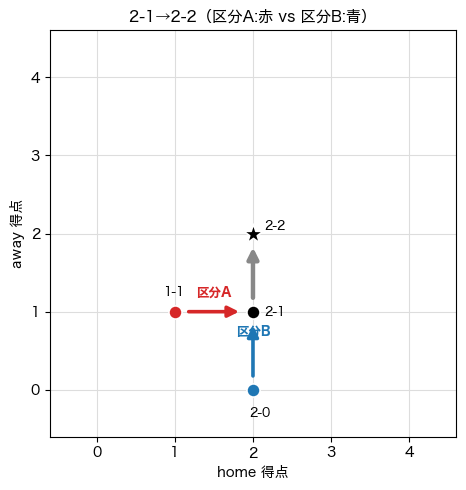

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 4, 4, "2-1→2-2（区分A:赤 vs 区分B:青）")
draw_point(ax, (1, 1), color=RED, label="1-1", label_offset=(-0.15, 0.2))
draw_point(ax, (2, 0), color=BLUE, label="2-0", label_offset=(-0.05, -0.35))
draw_point(ax, (2, 1), color="black", label="2-1", label_offset=(0.15, -0.05))
draw_point(ax, (2, 2), color="black", marker="*", size=220, label="2-2", label_offset=(0.15, 0.05))
draw_arrow(ax, (1, 1), (2, 1), RED, label="区分A")
draw_arrow(ax, (2, 0), (2, 1), BLUE, label="区分B")
draw_arrow(ax, (2, 1), (2, 2), GRAY, lw=3.2)
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_2_2_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 13. ヒストグラムのビンを共通化し、既存フォーマットで描画する（2-1→2-2）

セクション10と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用し、この2区分
（1-1経由・2-0経由）の最大待ち時間から共通のビン境界を決めて描画する。


最大待ち時間: 69.53分 -> ビン境界: 0〜70分（5分刻み、14ビン）
保存しました: ./figures/recent_score_2_1_to_2_2_histograms.png


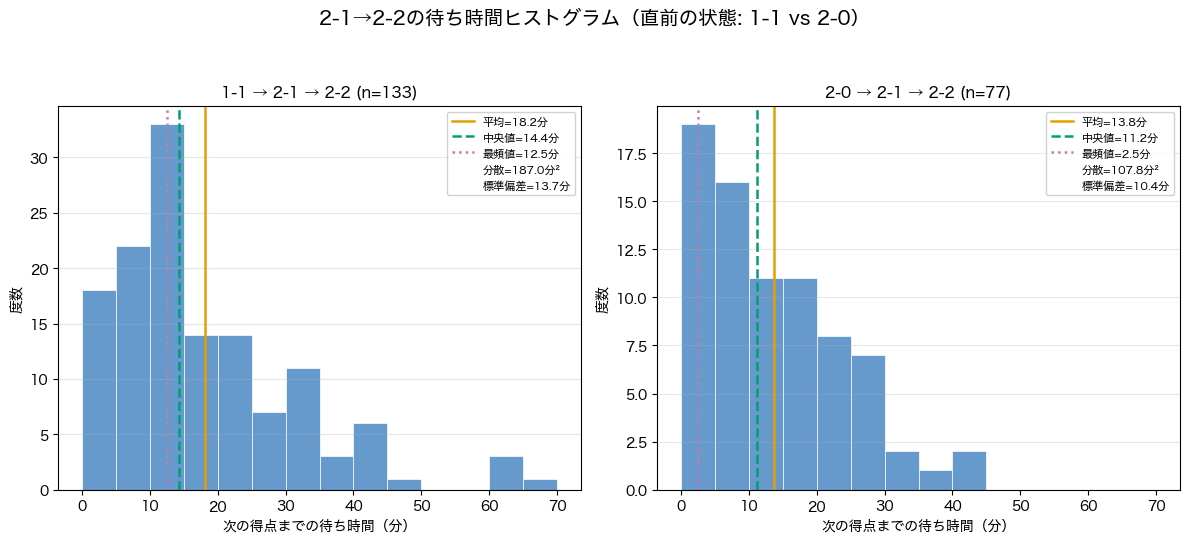

In [19]:
TRANSITION_22_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_22_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_22_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_22_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_22_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_22_stats = {}
for i, cat in enumerate(TRANSITION_22_CATEGORY_ORDER):
    vals = transition_22_events_df.loc[transition_22_events_df["category"] == cat, "waiting_time"].values
    transition_22_stats[cat] = plot_one(axes[i], vals, TRANSITION_22_CATEGORY_LABELS[cat], TRANSITION_22_BIN_EDGES)

fig.suptitle("2-1→2-2の待ち時間ヒストグラム（直前の状態: 1-1 vs 2-0）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_2_2_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 14. Kaplan-Meier曲線とログランク検定（1-1経由 vs 2-0経由・打ち切りなし、2-1→2-2）

セクション11と同様、`transition_22_events_df` の `waiting_time` をそのまま「イベント発生時間」
として扱う（`event_observed` は全件True、打ち切りなし）。1-1経由 vs 2-0経由の2群比較なので、
`lifelines.statistics.logrank_test` による標準的な2標本ログランク検定を行う。


保存しました: ./figures/recent_score_2_1_to_2_2_km_curves.png


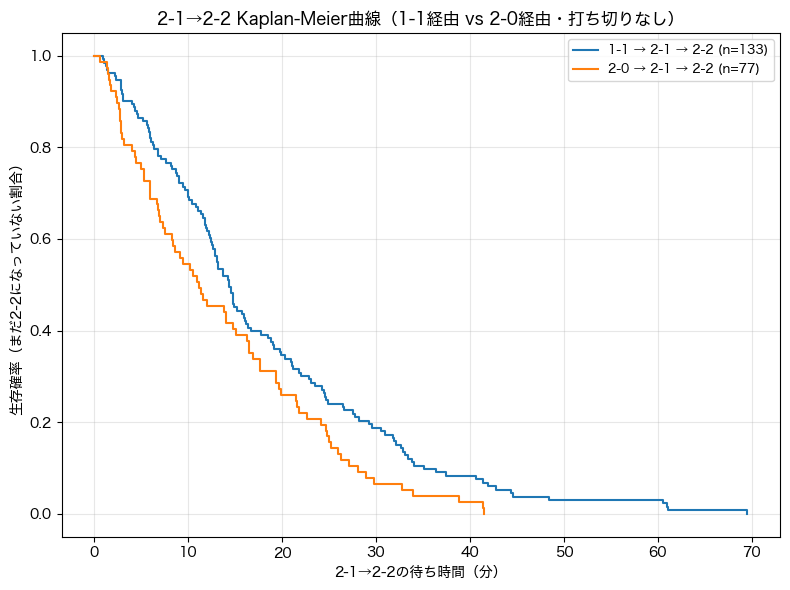

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_22 = KaplanMeierFitter()

for cat in TRANSITION_22_CATEGORY_ORDER:
    vals = transition_22_events_df.loc[transition_22_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_22.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_22_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_22.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("2-1→2-2の待ち時間（分）")
ax.set_ylabel("生存確率（まだ2-2になっていない割合）")
ax.set_title("2-1→2-2 Kaplan-Meier曲線（1-1経由 vs 2-0経由・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_1_to_2_2_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [21]:
from lifelines.statistics import logrank_test

vals_from_1_1_22 = transition_22_events_df.loc[transition_22_events_df["category"] == "from_1_1", "waiting_time"].values
vals_from_2_0_22 = transition_22_events_df.loc[transition_22_events_df["category"] == "from_2_0", "waiting_time"].values

logrank_result_22 = logrank_test(
    vals_from_1_1_22, vals_from_2_0_22,
    event_observed_A=None, event_observed_B=None,
)

print("=== 2-1→2-2の待ち時間: 1-1経由 vs 2-0経由 のログランク検定 ===")
print(f"n(1-1経由)={len(vals_from_1_1_22)}, n(2-0経由)={len(vals_from_2_0_22)}")
logrank_result_22.print_summary()
print(f"\np値: {logrank_result_22.p_value:.6e}{stars(logrank_result_22.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 2-1→2-2の待ち時間: 1-1経由 vs 2-0経由 のログランク検定 ===
n(1-1経由)=133, n(2-0経由)=77



p値: 1.187501e-02**
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 15. 4-2の遷移を計算する（3-2から拡大 vs 4-1から縮小で場合分け）

さらに一般化して、**リード側4点・ビハインド側2点（4-2）の状態に到達した試合**を対象に、
4-2になる直前の状態で場合分けして比較する。4-2の直前の状態は必ず「3-2」（リード側の得点）
か「4-1」（ビハインド側の得点）のいずれかである。

- **3-2 → 4-2**: 1点差リードを2点差に広げたケース
- **4-1 → 4-2**: 3点差リードを2点差に詰めたケース（ビハインド側が反撃）

**注**: セクション9・12と同様、ホーム・アウェイどちらがリードしているかは区別せず、リード側の
得点：ビハインド側の得点が4：2であれば「4-2」として扱う。4-2に到達する経路は必ずこの2通り
（3-2から拡大、または4-1から縮小）のいずれかであり、他の可能性はない。


In [22]:
TRANSITION_42_CATEGORY_LABELS = {
    "extend_1_to_2": "3-2 → 4-2（1点差→2点差に拡大）",
    "narrow_3_to_2": "4-1 → 4-2（3点差→2点差に縮小）",
}
TRANSITION_42_CATEGORY_ORDER = ["extend_1_to_2", "narrow_3_to_2"]


def build_4_2_events(df):
    """
    goals_and_red_cards の df から、試合ごとに得点系列（(home_score, away_score) の推移）を
    追跡し、リード側4点・ビハインド側2点（home/awayどちらがリードしていてもよい）の状態に
    到達した試合を対象に、その直前の状態から4-2になるまでの待ち時間を計算する。
    4-2の直前の状態は必ず「3-2相当」（リード側の得点で1点差→2点差に拡大）か
    「4-1相当」（ビハインド側の得点で3点差→2点差に縮小）のいずれかである。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]
        state_time = {(0, 0): 0.0}
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        # home がリードする (4, 2) と、away がリードする (2, 4) の両方を「4-2」として調べる
        for h, a in [(4, 2), (2, 4)]:
            idx = state_index.get((h, a))
            if idx is None or idx == 0:
                continue  # 4-2に到達していない

            prev_state = state_seq[idx - 1]
            if h == 4:
                prev_extend, prev_narrow = (3, 2), (4, 1)
            else:
                prev_extend, prev_narrow = (2, 3), (1, 4)

            if prev_state == prev_extend:
                category = "extend_1_to_2"
            elif prev_state == prev_narrow:
                category = "narrow_3_to_2"
            else:
                continue  # 理論上あり得ないが安全のため

            records.append({
                **meta, "category": category,
                "waiting_time": state_time[(h, a)] - state_time[prev_state],
            })

    return pd.DataFrame(records)


transition_42_events_df = build_4_2_events(df_all)
print(f"観測数: {len(transition_42_events_df)}")
transition_42_events_df["category"].value_counts().reindex(TRANSITION_42_CATEGORY_ORDER)


観測数: 59


category
extend_1_to_2    40
narrow_3_to_2    19
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_4_2_diagram.png


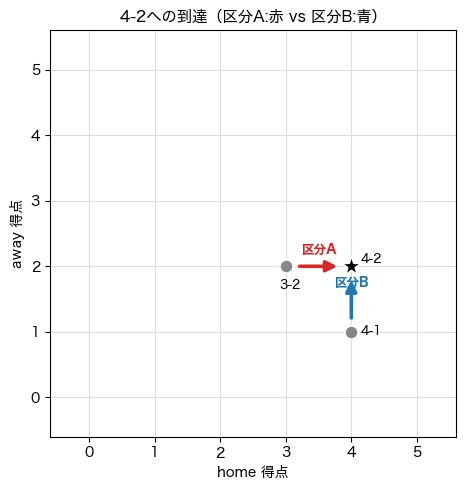

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 5, 5, "4-2への到達（区分A:赤 vs 区分B:青）")
draw_point(ax, (3, 2), color=GRAY, label="3-2", label_offset=(-0.1, -0.35))
draw_point(ax, (4, 1), color=GRAY, label="4-1", label_offset=(0.15, -0.05))
draw_point(ax, (4, 2), color="black", marker="*", size=220, label="4-2", label_offset=(0.15, 0.05))
draw_arrow(ax, (3, 2), (4, 2), RED, label="区分A")
draw_arrow(ax, (4, 1), (4, 2), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_2_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 16. ヒストグラムのビンを共通化し、既存フォーマットで描画する（4-2）

セクション10・13と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用する。4-2は2-1などに
比べて出現頻度が低い状態のため、ビン境界はこの2区分の最大待ち時間から改めて決める。


最大待ち時間: 42.48分 -> ビン境界: 0〜45分（5分刻み、9ビン）
保存しました: ./figures/recent_score_4_2_histograms.png


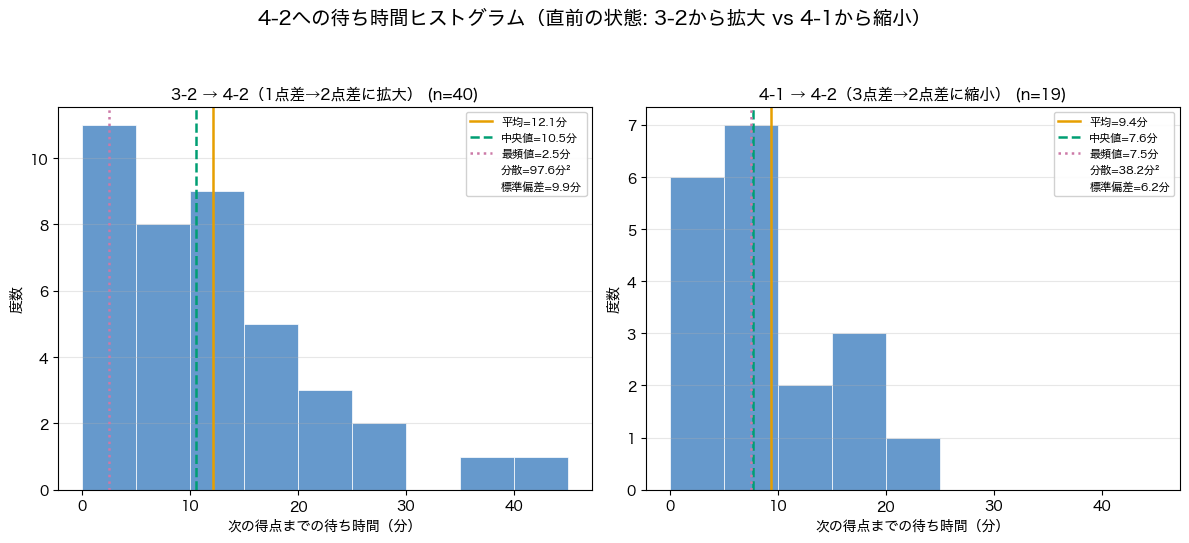

In [24]:
TRANSITION_42_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_42_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_42_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_42_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_42_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_42_stats = {}
for i, cat in enumerate(TRANSITION_42_CATEGORY_ORDER):
    vals = transition_42_events_df.loc[transition_42_events_df["category"] == cat, "waiting_time"].values
    transition_42_stats[cat] = plot_one(axes[i], vals, TRANSITION_42_CATEGORY_LABELS[cat], TRANSITION_42_BIN_EDGES)

fig.suptitle("4-2への待ち時間ヒストグラム（直前の状態: 3-2から拡大 vs 4-1から縮小）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_2_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 17. Kaplan-Meier曲線とログランク検定（3-2から拡大 vs 4-1から縮小・打ち切りなし、4-2）

セクション11・14と同様、`transition_42_events_df` の `waiting_time` をそのまま「イベント発生
時間」として扱う（`event_observed` は全件True、打ち切りなし）。3-2から拡大 vs 4-1から縮小の
2群比較なので、`lifelines.statistics.logrank_test` による標準的な2標本ログランク検定を行う。
4-2は2-1などに比べて出現頻度が低い状態であるため、標本数が少なく検定の検出力は低い点に
注意する。


保存しました: ./figures/recent_score_4_2_km_curves.png


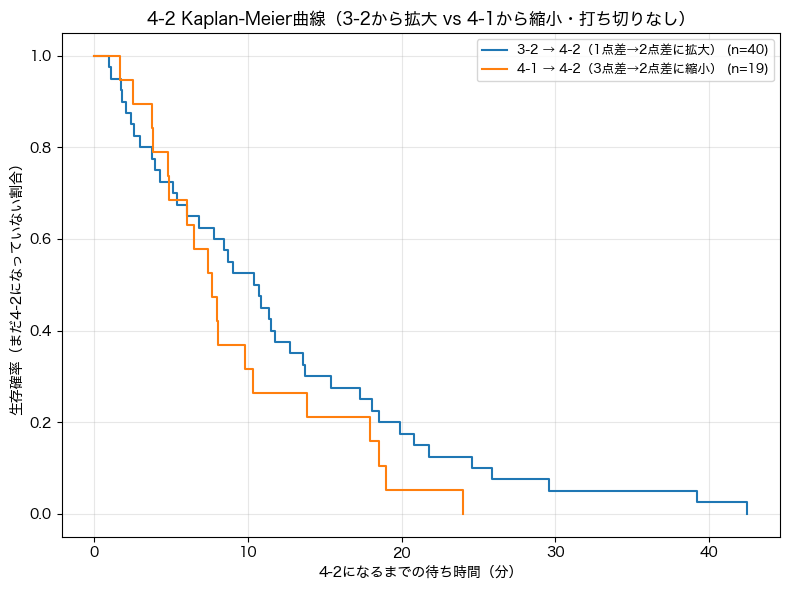

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_42 = KaplanMeierFitter()

for cat in TRANSITION_42_CATEGORY_ORDER:
    vals = transition_42_events_df.loc[transition_42_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_42.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_42_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_42.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("4-2になるまでの待ち時間（分）")
ax.set_ylabel("生存確率（まだ4-2になっていない割合）")
ax.set_title("4-2 Kaplan-Meier曲線（3-2から拡大 vs 4-1から縮小・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_2_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [26]:
from lifelines.statistics import logrank_test

vals_extend_42 = transition_42_events_df.loc[transition_42_events_df["category"] == "extend_1_to_2", "waiting_time"].values
vals_narrow_42 = transition_42_events_df.loc[transition_42_events_df["category"] == "narrow_3_to_2", "waiting_time"].values

logrank_result_42 = logrank_test(
    vals_extend_42, vals_narrow_42,
    event_observed_A=None, event_observed_B=None,
)

print("=== 4-2になるまでの待ち時間: 3-2から拡大 vs 4-1から縮小 のログランク検定 ===")
print(f"n(3-2から拡大)={len(vals_extend_42)}, n(4-1から縮小)={len(vals_narrow_42)}")
logrank_result_42.print_summary()
print(f"\np値: {logrank_result_42.p_value:.6e}{stars(logrank_result_42.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 4-2になるまでの待ち時間: 3-2から拡大 vs 4-1から縮小 のログランク検定 ===
n(3-2から拡大)=40, n(4-1から縮小)=19



p値: 1.926568e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 18. 3-2の遷移を計算する（2-2から破る vs 3-1から追撃で場合分け）

3-2（リード側3点・ビハインド側2点）について、直前の状態で場合分けする。3-2の直前の
状態は必ず「2-2」（同点を破ってリードを奪う）か「3-1」（ビハインド側が追撃して2点差から
1点差に詰める）のいずれかである。

- **2-2 → 3-2**: 同点を破ってリードを奪ったケース
- **3-1 → 3-2**: 2点差リードを1点差に詰めたケース（ビハインド側の反撃）

セクション15（4-2）のロジックを一般化した `build_arrival_events(df, leader_score, trailer_score)`
関数を新たに定義し、3-2・3-1（到達）・4-1で共通利用する。


In [27]:
def build_arrival_events(df, leader_score, trailer_score):
    """
    汎用ヘルパー: リード側 leader_score 点・ビハインド側 trailer_score 点
    （home/awayどちらがリードしていてもよい）の状態に到達した試合を対象に、その直前の
    状態から場合分けする。セクション12の build_4_2_events を一般化したもの
    （leader_score=4, trailer_score=2 とすれば build_4_2_events と同じ結果になる）。
      - "extend": (leader_score-1, trailer_score) から来た（リード側の得点で1点差拡大）
      - "narrow": (leader_score, trailer_score-1) から来た（ビハインド側の得点で追撃）
    trailer_score が0の場合は narrow 側の直前状態が存在しないため、narrow は生じない。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]
        state_time = {(0, 0): 0.0}
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        for h, a in [(leader_score, trailer_score), (trailer_score, leader_score)]:
            idx = state_index.get((h, a))
            if idx is None or idx == 0:
                continue  # 到達していない、または最初の得点でこの状態になっている(あり得ないが安全のため)

            prev_state = state_seq[idx - 1]
            if h == leader_score:
                extend_pred = (leader_score - 1, trailer_score)
                narrow_pred = (leader_score, trailer_score - 1)
            else:
                extend_pred = (trailer_score, leader_score - 1)
                narrow_pred = (trailer_score - 1, leader_score)

            if prev_state == extend_pred:
                category = "extend"
            elif trailer_score > 0 and prev_state == narrow_pred:
                category = "narrow"
            else:
                continue  # 理論上あり得ないが安全のため

            records.append({
                **meta, "category": category,
                "waiting_time": state_time[(h, a)] - state_time[prev_state],
            })

    return pd.DataFrame(records)


TRANSITION_32_CATEGORY_LABELS = {
    "extend": "2-2 → 3-2（同点を破ってリードを奪う）",
    "narrow": "3-1 → 3-2（2点差から1点差に追撃）",
}
TRANSITION_32_CATEGORY_ORDER = ["extend", "narrow"]

transition_32_events_df = build_arrival_events(df_all, 3, 2)
print(f"観測数: {len(transition_32_events_df)}")
transition_32_events_df["category"].value_counts().reindex(TRANSITION_32_CATEGORY_ORDER)


観測数: 161


category
extend    93
narrow    68
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_3_2_diagram.png


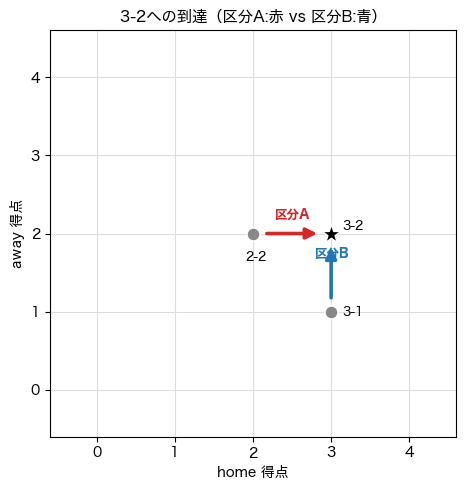

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 4, 4, "3-2への到達（区分A:赤 vs 区分B:青）")
draw_point(ax, (2, 2), color=GRAY, label="2-2", label_offset=(-0.1, -0.35))
draw_point(ax, (3, 1), color=GRAY, label="3-1", label_offset=(0.15, -0.05))
draw_point(ax, (3, 2), color="black", marker="*", size=220, label="3-2", label_offset=(0.15, 0.05))
draw_arrow(ax, (2, 2), (3, 2), RED, label="区分A")
draw_arrow(ax, (3, 1), (3, 2), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_2_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 19. ヒストグラムのビンを共通化し、既存フォーマットで描画する（3-2）

セクション16と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用する。


最大待ち時間: 48.82分 -> ビン境界: 0〜50分（5分刻み、10ビン）
保存しました: ./figures/recent_score_3_2_histograms.png


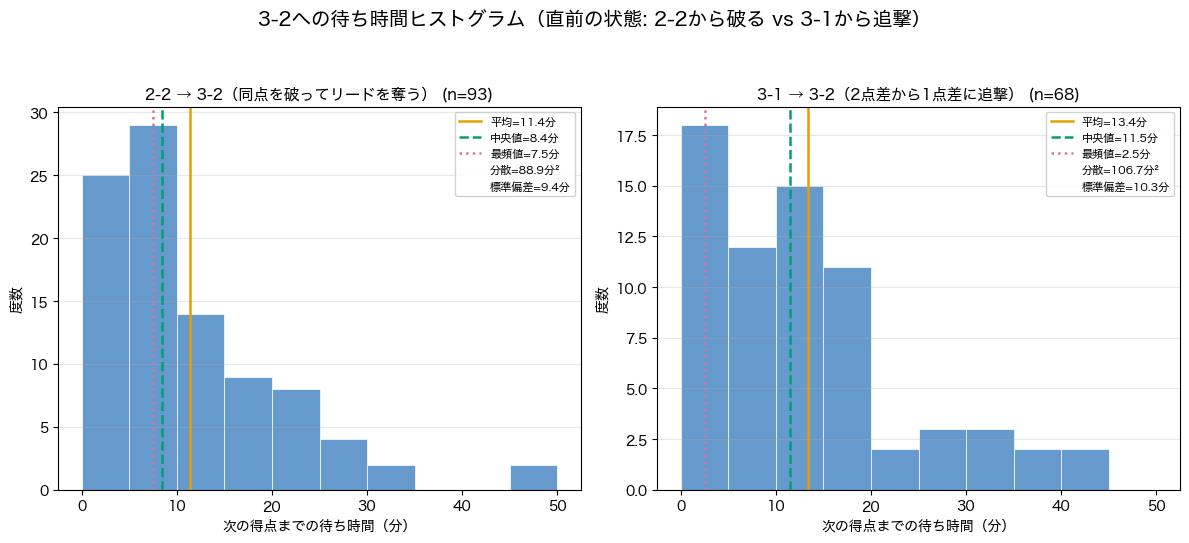

In [29]:
TRANSITION_32_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_32_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_32_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_32_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_32_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_32_stats = {}
for i, cat in enumerate(TRANSITION_32_CATEGORY_ORDER):
    vals = transition_32_events_df.loc[transition_32_events_df["category"] == cat, "waiting_time"].values
    transition_32_stats[cat] = plot_one(axes[i], vals, TRANSITION_32_CATEGORY_LABELS[cat], TRANSITION_32_BIN_EDGES)

fig.suptitle("3-2への待ち時間ヒストグラム（直前の状態: 2-2から破る vs 3-1から追撃）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_2_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 20. Kaplan-Meier曲線とログランク検定（2-2から破る vs 3-1から追撃・打ち切りなし、3-2）

`transition_32_events_df` の `waiting_time` をそのまま「イベント発生時間」として扱う
（`event_observed` は全件True、打ち切りなし）。2群比較なので `lifelines.statistics.logrank_test`
による標準的な2標本ログランク検定を行う。


保存しました: ./figures/recent_score_3_2_km_curves.png


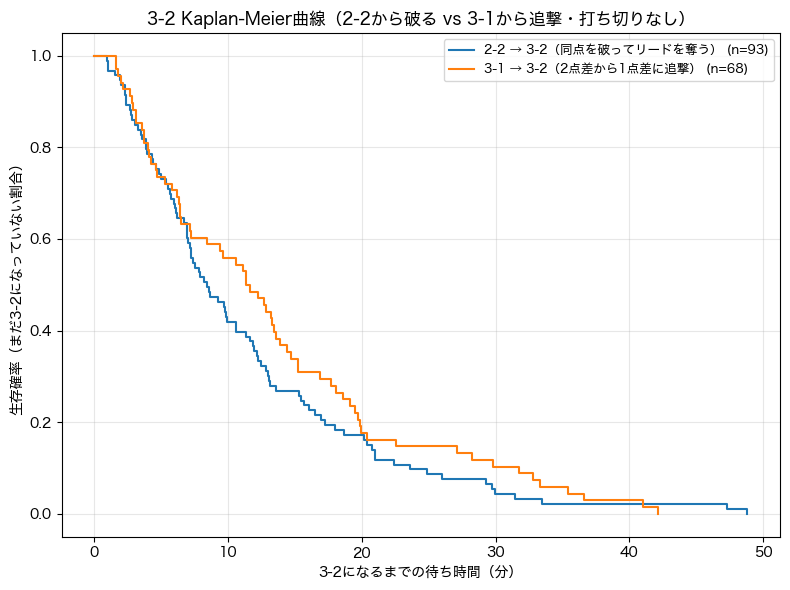

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_32 = KaplanMeierFitter()

for cat in TRANSITION_32_CATEGORY_ORDER:
    vals = transition_32_events_df.loc[transition_32_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_32.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_32_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_32.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("3-2になるまでの待ち時間（分）")
ax.set_ylabel("生存確率（まだ3-2になっていない割合）")
ax.set_title("3-2 Kaplan-Meier曲線（2-2から破る vs 3-1から追撃・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_2_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [31]:
from lifelines.statistics import logrank_test

vals_extend_32 = transition_32_events_df.loc[transition_32_events_df["category"] == "extend", "waiting_time"].values
vals_narrow_32 = transition_32_events_df.loc[transition_32_events_df["category"] == "narrow", "waiting_time"].values

logrank_result_32 = logrank_test(
    vals_extend_32, vals_narrow_32,
    event_observed_A=None, event_observed_B=None,
)

print("=== 3-2になるまでの待ち時間: 2-2から破る vs 3-1から追撃 のログランク検定 ===")
print(f"n(2-2から破る)={len(vals_extend_32)}, n(3-1から追撃)={len(vals_narrow_32)}")
logrank_result_32.print_summary()
print(f"\np値: {logrank_result_32.p_value:.6e}{stars(logrank_result_32.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 3-2になるまでの待ち時間: 2-2から破る vs 3-1から追撃 のログランク検定 ===
n(2-2から破る)=93, n(3-1から追撃)=68



p値: 2.581067e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 21. 3-1の遷移を計算する（2-1から拡大 vs 3-0から追撃で場合分け、到達ベース）

セクション9〜11では「2-1になった直後にリード側がさらに得点して3-1になった」試合を、
2-1になる直前の状態（1-1経由 vs 2-0経由）で場合分けした。ここでは視点を変え、**3-1という
状態そのものに到達した試合**を対象に、3-1になる直前の状態で場合分けする。3-1の直前の状態は
必ず「2-1」（リード側の得点で2点差に拡大）か「3-0」（ビハインド側が初めて得点し3点差から
2点差に詰める）のいずれかである。

- **2-1 → 3-1**: 1点差リードをさらに2点差に広げたケース（この集合自体はセクション9〜11の
  「2-1→3-1」に分類された試合と同じだが、比較対象がセクション9〜11とは異なる。セクション9〜11
  は「2-1になった直前の状態」で比較したのに対し、ここでは「3-1になった直前の状態」で比較する）
- **3-0 → 3-1**: 3点差リードされていたチーム（ビハインド側）が初めて得点し2点差に詰めたケース

`build_arrival_events` をそのまま再利用する（`leader_score=3, trailer_score=1`）。


In [32]:
TRANSITION_31_CATEGORY_LABELS = {
    "extend": "2-1 → 3-1（1点差リードを2点差に拡大）",
    "narrow": "3-0 → 3-1（3点差から2点差に追撃）",
}
TRANSITION_31_CATEGORY_ORDER = ["extend", "narrow"]

transition_31_events_df = build_arrival_events(df_all, 3, 1)
print(f"観測数: {len(transition_31_events_df)}")
transition_31_events_df["category"].value_counts().reindex(TRANSITION_31_CATEGORY_ORDER)


観測数: 349


category
extend    261
narrow     88
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_3_1_arrival_diagram.png


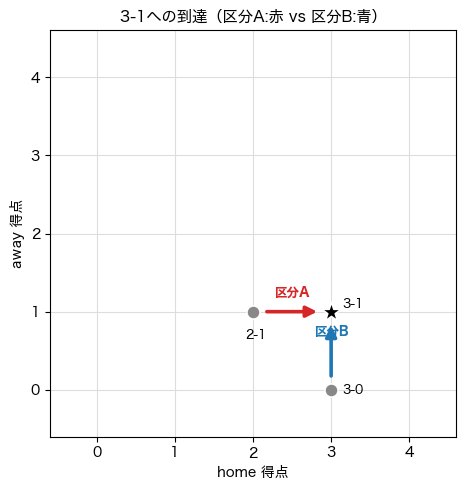

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 4, 4, "3-1への到達（区分A:赤 vs 区分B:青）")
draw_point(ax, (2, 1), color=GRAY, label="2-1", label_offset=(-0.1, -0.35))
draw_point(ax, (3, 0), color=GRAY, label="3-0", label_offset=(0.15, -0.05))
draw_point(ax, (3, 1), color="black", marker="*", size=220, label="3-1", label_offset=(0.15, 0.05))
draw_arrow(ax, (2, 1), (3, 1), RED, label="区分A")
draw_arrow(ax, (3, 0), (3, 1), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_1_arrival_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 22. ヒストグラムのビンを共通化し、既存フォーマットで描画する（3-1・到達ベース）

セクション19と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用する。


最大待ち時間: 75.08分 -> ビン境界: 0〜80分（5分刻み、16ビン）
保存しました: ./figures/recent_score_3_1_arrival_histograms.png


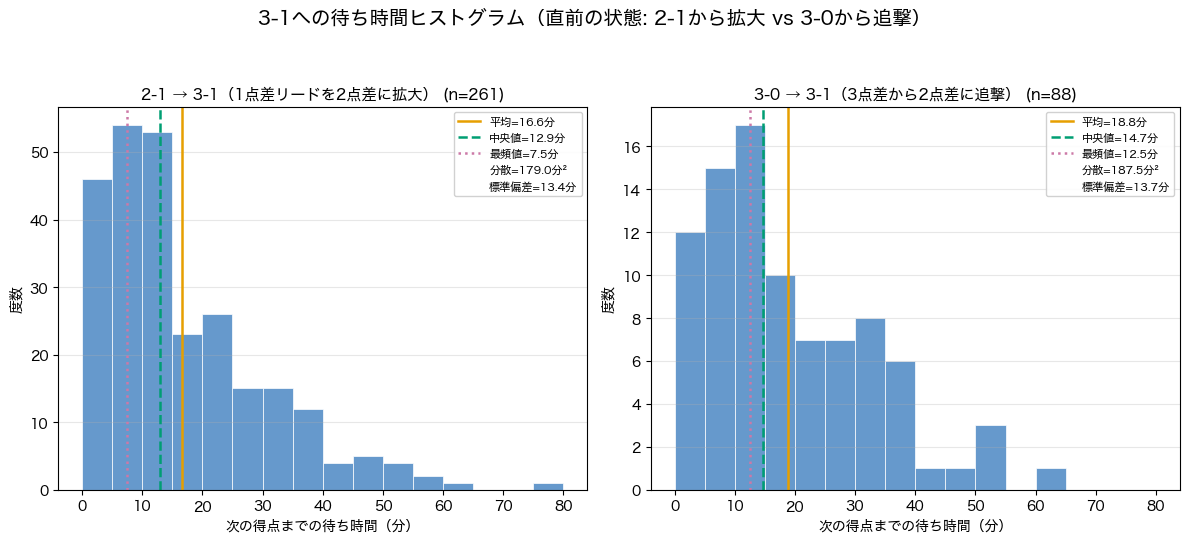

In [34]:
TRANSITION_31_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_31_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_31_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_31_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_31_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_31_stats = {}
for i, cat in enumerate(TRANSITION_31_CATEGORY_ORDER):
    vals = transition_31_events_df.loc[transition_31_events_df["category"] == cat, "waiting_time"].values
    transition_31_stats[cat] = plot_one(axes[i], vals, TRANSITION_31_CATEGORY_LABELS[cat], TRANSITION_31_BIN_EDGES)

fig.suptitle("3-1への待ち時間ヒストグラム（直前の状態: 2-1から拡大 vs 3-0から追撃）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_1_arrival_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 23. Kaplan-Meier曲線とログランク検定（2-1から拡大 vs 3-0から追撃・打ち切りなし、3-1・到達ベース）

`transition_31_events_df` の `waiting_time` をそのまま「イベント発生時間」として扱う
（`event_observed` は全件True、打ち切りなし）。2群比較なので `lifelines.statistics.logrank_test`
による標準的な2標本ログランク検定を行う。


保存しました: ./figures/recent_score_3_1_arrival_km_curves.png


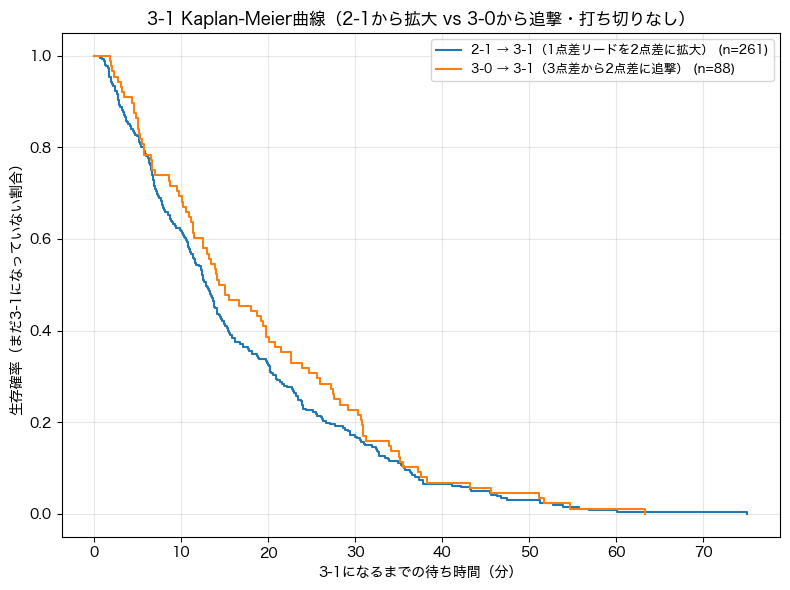

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_31 = KaplanMeierFitter()

for cat in TRANSITION_31_CATEGORY_ORDER:
    vals = transition_31_events_df.loc[transition_31_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_31.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_31_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_31.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("3-1になるまでの待ち時間（分）")
ax.set_ylabel("生存確率（まだ3-1になっていない割合）")
ax.set_title("3-1 Kaplan-Meier曲線（2-1から拡大 vs 3-0から追撃・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_3_1_arrival_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [36]:
vals_extend_31 = transition_31_events_df.loc[transition_31_events_df["category"] == "extend", "waiting_time"].values
vals_narrow_31 = transition_31_events_df.loc[transition_31_events_df["category"] == "narrow", "waiting_time"].values

logrank_result_31 = logrank_test(
    vals_extend_31, vals_narrow_31,
    event_observed_A=None, event_observed_B=None,
)

print("=== 3-1になるまでの待ち時間: 2-1から拡大 vs 3-0から追撃 のログランク検定 ===")
print(f"n(2-1から拡大)={len(vals_extend_31)}, n(3-0から追撃)={len(vals_narrow_31)}")
logrank_result_31.print_summary()
print(f"\np値: {logrank_result_31.p_value:.6e}{stars(logrank_result_31.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 3-1になるまでの待ち時間: 2-1から拡大 vs 3-0から追撃 のログランク検定 ===
n(2-1から拡大)=261, n(3-0から追撃)=88



p値: 2.790931e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 24. 4-1の遷移を計算する（3-1から拡大 vs 4-0から追撃で場合分け）

同様に、**リード側4点・ビハインド側1点（4-1）の状態に到達した試合**を対象に、4-1になる
直前の状態で場合分けする。4-1の直前の状態は必ず「3-1」（リード側の得点で3点差に拡大）か
「4-0」（ビハインド側が初めて得点し4点差から3点差に詰める）のいずれかである。

- **3-1 → 4-1**: 2点差リードをさらに3点差に広げたケース
- **4-0 → 4-1**: 4点差リードされていたチームが初めて得点し3点差に詰めたケース

`build_arrival_events` を再利用する（`leader_score=4, trailer_score=1`）。


In [37]:
TRANSITION_41_CATEGORY_LABELS = {
    "extend": "3-1 → 4-1（2点差リードを3点差に拡大）",
    "narrow": "4-0 → 4-1（4点差から3点差に追撃）",
}
TRANSITION_41_CATEGORY_ORDER = ["extend", "narrow"]

transition_41_events_df = build_arrival_events(df_all, 4, 1)
print(f"観測数: {len(transition_41_events_df)}")
transition_41_events_df["category"].value_counts().reindex(TRANSITION_41_CATEGORY_ORDER)


観測数: 145


category
extend    116
narrow     29
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_4_1_diagram.png


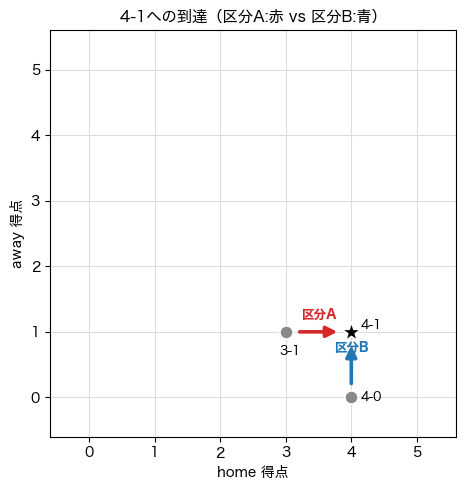

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 5, 5, "4-1への到達（区分A:赤 vs 区分B:青）")
draw_point(ax, (3, 1), color=GRAY, label="3-1", label_offset=(-0.1, -0.35))
draw_point(ax, (4, 0), color=GRAY, label="4-0", label_offset=(0.15, -0.05))
draw_point(ax, (4, 1), color="black", marker="*", size=220, label="4-1", label_offset=(0.15, 0.05))
draw_arrow(ax, (3, 1), (4, 1), RED, label="区分A")
draw_arrow(ax, (4, 0), (4, 1), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_1_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 25. ヒストグラムのビンを共通化し、既存フォーマットで描画する（4-1）

セクション19・22と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用する。


最大待ち時間: 45.08分 -> ビン境界: 0〜50分（5分刻み、10ビン）
保存しました: ./figures/recent_score_4_1_histograms.png


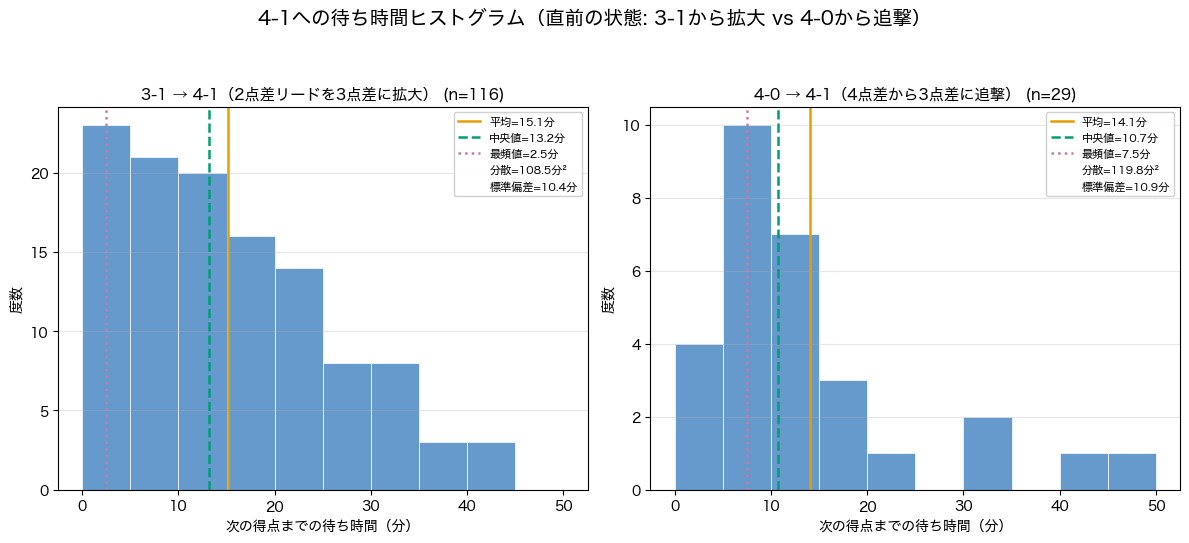

In [39]:
TRANSITION_41_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_41_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_41_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_41_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_41_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_41_stats = {}
for i, cat in enumerate(TRANSITION_41_CATEGORY_ORDER):
    vals = transition_41_events_df.loc[transition_41_events_df["category"] == cat, "waiting_time"].values
    transition_41_stats[cat] = plot_one(axes[i], vals, TRANSITION_41_CATEGORY_LABELS[cat], TRANSITION_41_BIN_EDGES)

fig.suptitle("4-1への待ち時間ヒストグラム（直前の状態: 3-1から拡大 vs 4-0から追撃）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_1_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 26. Kaplan-Meier曲線とログランク検定（3-1から拡大 vs 4-0から追撃・打ち切りなし、4-1）

`transition_41_events_df` の `waiting_time` をそのまま「イベント発生時間」として扱う
（`event_observed` は全件True、打ち切りなし）。2群比較なので `lifelines.statistics.logrank_test`
による標準的な2標本ログランク検定を行う。4-1は2-1などに比べて出現頻度が低い状態であるため、
標本数（特に少数派の「4-0から追撃」側、n=29）が少なく検定の検出力は低い点に注意する。


保存しました: ./figures/recent_score_4_1_km_curves.png


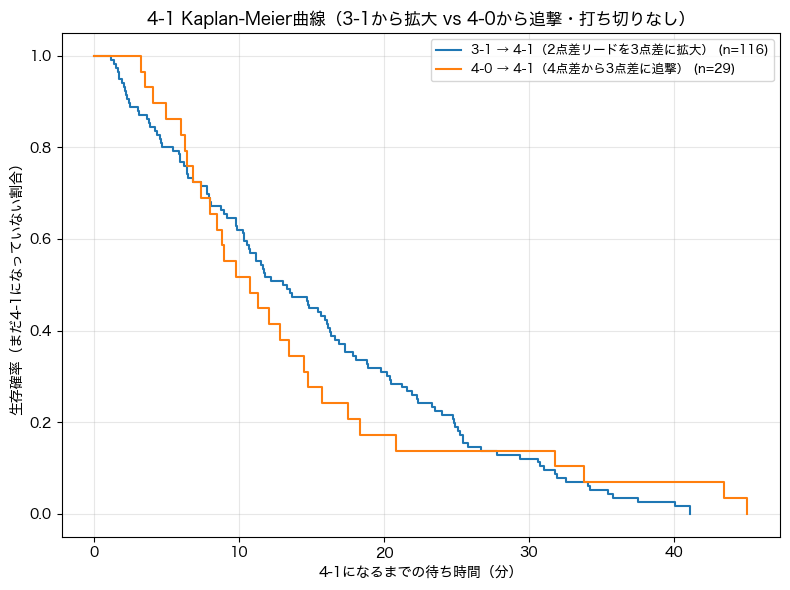

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_41 = KaplanMeierFitter()

for cat in TRANSITION_41_CATEGORY_ORDER:
    vals = transition_41_events_df.loc[transition_41_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_41.fit(durations=vals, event_observed=None,
                           label=f"{TRANSITION_41_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_41.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("4-1になるまでの待ち時間（分）")
ax.set_ylabel("生存確率（まだ4-1になっていない割合）")
ax.set_title("4-1 Kaplan-Meier曲線（3-1から拡大 vs 4-0から追撃・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_4_1_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [41]:
vals_extend_41 = transition_41_events_df.loc[transition_41_events_df["category"] == "extend", "waiting_time"].values
vals_narrow_41 = transition_41_events_df.loc[transition_41_events_df["category"] == "narrow", "waiting_time"].values

logrank_result_41 = logrank_test(
    vals_extend_41, vals_narrow_41,
    event_observed_A=None, event_observed_B=None,
)

print("=== 4-1になるまでの待ち時間: 3-1から拡大 vs 4-0から追撃 のログランク検定 ===")
print(f"n(3-1から拡大)={len(vals_extend_41)}, n(4-0から追撃)={len(vals_narrow_41)}")
logrank_result_41.print_summary()
print(f"\np値: {logrank_result_41.p_value:.6e}{stars(logrank_result_41.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 4-1になるまでの待ち時間: 3-1から拡大 vs 4-0から追撃 のログランク検定 ===
n(3-1から拡大)=116, n(4-0から追撃)=29



p値: 9.870036e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 27. 2-2からの遷移を計算する（追いついた側が次に得点 vs 追いつかれた側が次に得点で場合分け）

セクション6では1-1という特定の同点状態から次にどちらが得点するかを調べた。ここではそれを
一般化し、**2-2という同点状態**についても同様の分析を行う（1-2→2-2、2-1→2-2のどちらの経路
で2-2に至ったかは区別せず、2-2に到達した試合をすべて対象とする）。

- **追いついた側が次に得点**: 2-2に追いついた勢いのまま、そのチームが続けて先取点を奪うケース
- **追いつかれた側が次に得点**: 2-2に追いつかれた直後に、元のリード側が再び得点し突き放すケース

セクション6の `build_1_1_transition_events` を一般化した `build_tie_forward_events(df, tie_score)`
関数を新たに定義する（`tie_score=1` とすればセクション6と同じ結果になる）。同じ枠組みで3-3
についても分析可能だが、実際のデータでは3-3に到達する試合が9件（うち少数派4件）しかなく
標本数が不十分なため、今回は対象外とする（本セクション群冒頭の表を参照）。


In [42]:
def build_tie_forward_events(df, tie_score):
    """
    汎用ヘルパー: ちょうど (tie_score, tie_score) の同点状態に到達した試合を対象に、その
    直後に次に得点したのが「追いついた側(leveler_next)」か「追いつかれた側
    (original_leader_next)」かで category を分ける。セクション15の
    build_1_1_transition_events を一般化したもの（tie_score=1とすれば同じ結果になる）。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        times = g["time_min"].to_numpy()
        sides = g["home_away"].to_numpy()  # 0=home, 1=away
        meta = dict(league_code=league_code, season_name=season_name, match_id=match_id)

        home_score = away_score = 0
        state_seq = [(0, 0)]
        state_time = {(0, 0): 0.0}
        for t, s in zip(times, sides):
            if s == 0:
                home_score += 1
            else:
                away_score += 1
            state = (home_score, away_score)
            state_seq.append(state)
            state_time[state] = t
        state_index = {state: i for i, state in enumerate(state_seq)}

        idx = state_index.get((tie_score, tie_score))
        if idx is None or idx == 0:
            continue  # この試合はtie_score-tie_scoreの同点にならなかった（idx==0は0-0で対象外）

        leveler_side = sides[idx - 1]  # 同点にした側（追いついた側）

        if idx >= len(state_seq) - 1:
            continue  # 同点が試合最後の得点で、その後得点がない（除外）

        next_side = sides[idx]  # 同点の直後に実際に得点したチーム
        category = "leveler_next" if next_side == leveler_side else "original_leader_next"
        waiting_time = state_time[state_seq[idx + 1]] - state_time[(tie_score, tie_score)]

        records.append({**meta, "category": category, "waiting_time": waiting_time})

    return pd.DataFrame(records)


TRANSITION_TIE22_CATEGORY_LABELS = {
    "leveler_next": "追いついた側が次に得点",
    "original_leader_next": "追いつかれた側が次に得点",
}
TRANSITION_TIE22_CATEGORY_ORDER = ["leveler_next", "original_leader_next"]

transition_tie22_events_df = build_tie_forward_events(df_all, 2)
print(f"観測数: {len(transition_tie22_events_df)}")
transition_tie22_events_df["category"].value_counts().reindex(TRANSITION_TIE22_CATEGORY_ORDER)


観測数: 93


category
leveler_next            41
original_leader_next    52
Name: count, dtype: int64

### 概念図

区分A（赤）・区分B（青）を、home×awayグリッド上の矢印として図示する。


保存しました: ./figures/recent_score_2_2_transition_diagram.png


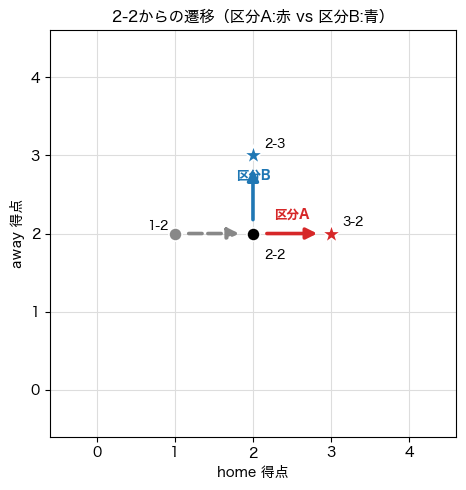

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))
draw_score_grid(ax, 4, 4, "2-2からの遷移（区分A:赤 vs 区分B:青）")
draw_point(ax, (1, 2), color=GRAY, label="1-2", label_offset=(-0.35, 0.05))
draw_point(ax, (2, 2), color="black", label="2-2", label_offset=(0.15, -0.32))
draw_point(ax, (3, 2), color=RED, marker="*", size=220, label="3-2")
draw_point(ax, (2, 3), color=BLUE, marker="*", size=220, label="2-3")
draw_arrow(ax, (1, 2), (2, 2), GRAY, style="--")
draw_arrow(ax, (2, 2), (3, 2), RED, label="区分A")
draw_arrow(ax, (2, 2), (2, 3), BLUE, label="区分B")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_2_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 28. ヒストグラムのビンを共通化し、既存フォーマットで描画する（2-2からの遷移）

セクション7と同様、`BIN_WIDTH`・`compute_stats`・`plot_one` を再利用する。


最大待ち時間: 48.82分 -> ビン境界: 0〜50分（5分刻み、10ビン）
保存しました: ./figures/recent_score_2_2_transition_histograms.png


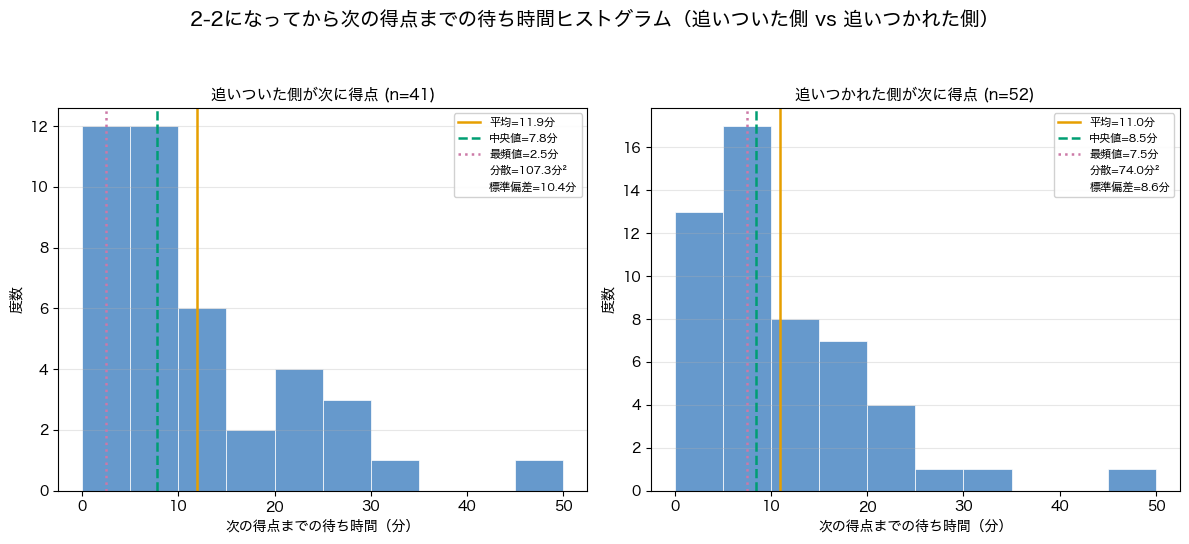

In [44]:
TRANSITION_TIE22_BIN_EDGES = np.arange(
    0,
    np.ceil(transition_tie22_events_df["waiting_time"].max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH,
    BIN_WIDTH,
)
print(f"最大待ち時間: {transition_tie22_events_df['waiting_time'].max():.2f}分 -> "
      f"ビン境界: 0〜{TRANSITION_TIE22_BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(TRANSITION_TIE22_BIN_EDGES)-1}ビン）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

transition_tie22_stats = {}
for i, cat in enumerate(TRANSITION_TIE22_CATEGORY_ORDER):
    vals = transition_tie22_events_df.loc[transition_tie22_events_df["category"] == cat, "waiting_time"].values
    transition_tie22_stats[cat] = plot_one(axes[i], vals, TRANSITION_TIE22_CATEGORY_LABELS[cat], TRANSITION_TIE22_BIN_EDGES)

fig.suptitle("2-2になってから次の得点までの待ち時間ヒストグラム（追いついた側 vs 追いつかれた側）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.93])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_2_transition_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 29. Kaplan-Meier曲線とログランク検定（追いついた側 vs 追いつかれた側・打ち切りなし、2-2からの遷移）

セクション8と同様、`transition_tie22_events_df` の `waiting_time` をそのまま「イベント発生
時間」として扱う（`event_observed` は全件True、打ち切りなし）。2群比較なので
`lifelines.statistics.logrank_test` による標準的な2標本ログランク検定を行う。


保存しました: ./figures/recent_score_2_2_transition_km_curves.png


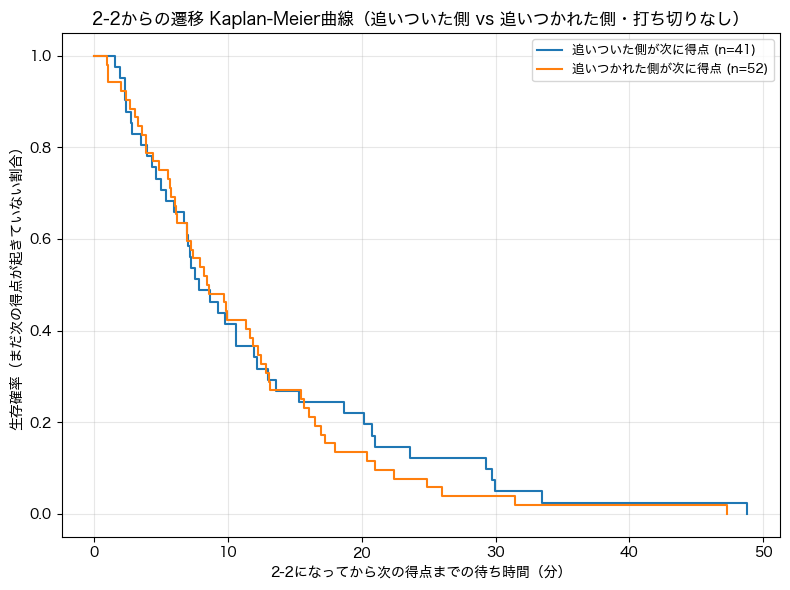

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
kmf_transition_tie22 = KaplanMeierFitter()

for cat in TRANSITION_TIE22_CATEGORY_ORDER:
    vals = transition_tie22_events_df.loc[transition_tie22_events_df["category"] == cat, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf_transition_tie22.fit(durations=vals, event_observed=None,
                              label=f"{TRANSITION_TIE22_CATEGORY_LABELS[cat]} (n={len(vals)})")
    kmf_transition_tie22.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("2-2になってから次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ次の得点が起きていない割合）")
ax.set_title("2-2からの遷移 Kaplan-Meier曲線（追いついた側 vs 追いつかれた側・打ち切りなし）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/recent_score_2_2_transition_km_curves.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [46]:
vals_leveler_tie22 = transition_tie22_events_df.loc[transition_tie22_events_df["category"] == "leveler_next", "waiting_time"].values
vals_original_leader_tie22 = transition_tie22_events_df.loc[transition_tie22_events_df["category"] == "original_leader_next", "waiting_time"].values

logrank_result_tie22 = logrank_test(
    vals_leveler_tie22, vals_original_leader_tie22,
    event_observed_A=None, event_observed_B=None,
)

print("=== 2-2からの遷移: 追いついた側 vs 追いつかれた側 のログランク検定 ===")
print(f"n(追いついた側)={len(vals_leveler_tie22)}, n(追いつかれた側)={len(vals_original_leader_tie22)}")
logrank_result_tie22.print_summary()
print(f"\np値: {logrank_result_tie22.p_value:.6e}{stars(logrank_result_tie22.p_value)}")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")


=== 2-2からの遷移: 追いついた側 vs 追いつかれた側 のログランク検定 ===
n(追いついた側)=41, n(追いつかれた側)=52



p値: 5.874402e-01
有意水準: * p<0.10, ** p<0.05, *** p<0.01


## 注意点・拡張のヒント

- **区分1〜4は「そのチーム自身の次の得点」が観測できたケースのみ**を対象にしている
  （そのままリード/ビハインドの側が試合終了まで得点しなかった場合は打ち切りとして除外）。
  そのため、例えば「ビハインド中・直近得点チーム」（区分3）と「リード中・直近得点していない
  チーム」（区分2）はどちらも「トレーリング側が得点した直後」から生じる観測だが、
  それぞれ別々の打ち切り条件（トレーリング側 or リード側が以降に得点するか）で選別されるため、
  標本数は一致しない。
- **最頻値**はヒストグラムのビン（5分刻み）に依存した近似値であり、ビン幅を変えると値も変わりうる。
- リーグ・シーズンごとの違いを見たい場合は、`events_df` に残した `league_code` / `season_name`
  で `groupby` すればよい（現状は全リーグ込みで集計している）。
